# Data Insights and Predictions in Formula 1 Races

Authors: Jameson Cohen, Quinn Donovan, Anthony Fletcher, and Trey Whitehead

LINK TO KAGGLE DATA: https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020/data

*Disclaimer: ChatGPT has been used to correct syntax in various places throughtout the notebook. In our final report, we intend to include a full attribution and detail all places where the it helped us.**



# SECTION 1: OVERVIEW









## 1.1: Introduction

New introduction: Forbes reports that Formula One drew in a record-setting number of fans in $2023$, exceeding its pre-COVID totals. Exploding in popularity, Formula One stands at the intersection of sport and technology, captivating global audiences with its high-speed thrills and cutting-edge innovation. As teams push the limits of engineering and strategy, F1's future looks brighter than ever; as new fans and budding data scientists, we want to model what determines F1 success on a season-by-season basis. We want to figure out who is poised to win.


## 1.2: Finalized Research Question (adjusted from MS3)

Leveraging historical performance data, constructor strength, and various driver attributes, can we reliably predict with over 75% accuracy the quartile in which an F1 driver will finish during a given race?

## 1.3 The General Approach



The Random Forest Classifier model starts by merging the results DataFrame with the races DataFrame to incorporate the race year. Elo ratings are then computed for each driver based on their race performance, with the scores updated after every race. Next, key features such as Elo scores, grid position, and fastest lap speed are extracted, while a new target variable, position_bucket, is created to categorize drivers' finishing positions into four quartiles based on their rank. The dataset is then split into training (up to 2022), validation (2023), and test (2024) sets. Both a Random Forest model and an XGBoost model are trained using the selected features and target variable. The models' performance is evaluated on the validation set using accuracy and F1-score metrics. After hyperparameter tuning, the models are retrained on the combined training and validation data and tested on the final test set to assess their generalization performance. Finally, the models' results are analyzed, insightful visualizations are provided, and a roadmap for completing the project is proposed.

# SECTION 2: INITIAL DATASET INVESTIGATION AND MISSINGNESS ANALYSIS

## 2.1: Preliminary Dataset Analysis

In this subsection, we will explore each of the affiliated dataframes in a dictionary of dataframes. We will import our data directly from Kaggle, conduct, examine missingness in our collection, and determine the data type of each column in each csv (and undertake any necessary preprocessing steps).

### Step 2.1.1: Importing the Dataset

In [ ]:
import os
import numpy as np
import kagglehub
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import folium
from IPython.display import display
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
# Download dataset
path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")
print("Path to dataset files:", path)

# List all CSV files in the directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV files in dataset:", csv_files)

# Load each CSV file into a dictionary of DataFrames
dataframes = {}
for csv_file in csv_files:
    file_path = os.path.join(path, csv_file)
    dataframes[csv_file] = pd.read_csv(file_path)

100%|██████████| 6.14M/6.14M [00:00<00:00, 28.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rohanrao/formula-1-world-championship-1950-2020/versions/23
CSV files in dataset: ['qualifying.csv', 'lap_times.csv', 'drivers.csv', 'pit_stops.csv', 'seasons.csv', 'constructor_standings.csv', 'driver_standings.csv', 'status.csv', 'sprint_results.csv', 'circuits.csv', 'races.csv', 'constructors.csv', 'results.csv', 'constructor_results.csv']


In [ ]:
# Quick scan of dataset (un-hide output to view)
for csv in csv_files:
    print(csv)
    display(dataframes[csv].head(10))

qualifying.csv


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236
5,6,18,15,7,11,6,1:26.427,1:26.101,1:28.527
6,7,18,3,3,7,7,1:26.295,1:26.059,1:28.687
7,8,18,14,9,9,8,1:26.381,1:26.063,1:29.041
8,9,18,10,7,12,9,1:26.919,1:26.164,1:29.593
9,10,18,20,5,15,10,1:26.702,1:25.842,\N


lap_times.csv


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342
5,841,20,6,1,1:32.605,92605
6,841,20,7,1,1:32.502,92502
7,841,20,8,1,1:32.537,92537
8,841,20,9,1,1:33.240,93240
9,841,20,10,1,1:32.572,92572


drivers.csv


...

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso
5,6,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari
6,7,toyota,Toyota,Japanese,http://en.wikipedia.org/wiki/Toyota_Racing
7,8,super_aguri,Super Aguri,Japanese,http://en.wikipedia.org/wiki/Super_Aguri_F1
8,9,red_bull,Red Bull,Austrian,http://en.wikipedia.org/wiki/Red_Bull_Racing
9,10,force_india,Force India,Indian,http://en.wikipedia.org/wiki/Racing_Point_Forc...


results.csv


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1
5,6,18,6,3,8,13,6,6,6,3.0,57,\N,\N,50,14,1:29.639,212.974,11
6,7,18,7,5,14,17,7,7,7,2.0,55,\N,\N,54,8,1:29.534,213.224,5
7,8,18,8,6,1,15,8,8,8,1.0,53,\N,\N,20,4,1:27.903,217.180,5
8,9,18,9,2,4,2,\N,R,9,0.0,47,\N,\N,15,9,1:28.753,215.100,4
9,10,18,10,7,12,18,\N,R,10,0.0,43,\N,\N,23,13,1:29.558,213.166,3


constructor_results.csv


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,\N
1,2,18,2,8.0,\N
2,3,18,3,9.0,\N
3,4,18,4,5.0,\N
4,5,18,5,2.0,\N
5,6,18,6,1.0,\N
6,7,18,7,0.0,\N
7,8,18,8,0.0,\N
8,9,18,9,0.0,\N
9,10,18,10,0.0,\N


### 2.1.2: Tackling Missingness

Upon inspection, we have identified two types of missing entries in our data.
- There is a small count of null entries
- Most missing data is represented with the substring '\N'

Let's begin to examine missingness by recasting all of our data as null:

In [ ]:
# Function for converting \N substrings to null
def replace_substring_with_null(dataframes, substring='\\N'):
    for df_name, df in dataframes.items():
        # Replace occurrences of the substring with NaN
        df.replace(substring, np.nan, inplace=True)

    return dataframes

updated_dataframes = replace_substring_with_null(dataframes, substring='\\N')

In [ ]:
# List to collect results
missing_results = []

for df_name, df in updated_dataframes.items():
    missing_count = df.isnull().sum()
    missing_count = missing_count[missing_count > 0]

    # Add to results list if there are missing values
    for column, count in missing_count.items():
        missing_results.append({
            "DataFrame": df_name,
            "Column": column,
            "Missing Entries": count,
            "Data Type": df[column].dtype
        })

# Display results
missing_results_df = pd.DataFrame(missing_results)
display(missing_results_df)


,DataFrame,Column,Missing Entries,Data Type
0,qualifying.csv,q1,154,object
1,qualifying.csv,q2,4585,object
2,qualifying.csv,q3,6740,object
3,drivers.csv,number,802,object
4,drivers.csv,code,757,object
5,sprint_results.csv,position,15,object
6,sprint_results.csv,time,19,object
7,sprint_results.csv,milliseconds,19,object
8,sprint_results.csv,fastestLap,9,object
9,sprint_results.csv,fastestLapTime,9,object


### 2.1.3: Looking at Datatype by Column

In this subsection, we investigate columns by type. Then, we count the number of type

In [ ]:
column_info = []

# Iterate through each DataFrame in the dictionary
for df_name, df in updated_dataframes.items():
    for column in df.columns:
        # Append a dictionary witheach column's datatype
        column_info.append({
            "CSV File": df_name,
            "Column Name": column,
            "Data Type": df[column].dtype
        })


columns_summary_df = pd.DataFrame(column_info)
columns_summary_df.head(10)

,CSV File,Column Name,Data Type
0,qualifying.csv,qualifyId,int64
1,qualifying.csv,raceId,int64
2,qualifying.csv,driverId,int64
3,qualifying.csv,constructorId,int64
4,qualifying.csv,number,int64
5,qualifying.csv,position,int64
6,qualifying.csv,q1,object
7,qualifying.csv,q2,object
8,qualifying.csv,q3,object
9,lap_times.csv,raceId,int64


In [ ]:
def count_columns_by_data_type(dataframes):
    # Initialize a dictionary to count columns by data type
    data_type_counts = {}

    # Iterate through each df in the dictionary
    for df_name, df in dataframes.items():
        for column in df.columns:
            data_type = df[column].dtype

            # Increment the count for this data type
            if data_type in data_type_counts:
                data_type_counts[data_type] += 1
            else:
                data_type_counts[data_type] = 1

    # Convert the counts dictionary into a df
    data_type_summary_df = pd.DataFrame(data_type_counts.items(), columns=['Data Type', 'Number of Columns'])
    return data_type_summary_df

data_type_summary = count_columns_by_data_type(updated_dataframes)
data_type_summary

,Data Type,Number of Columns
0,int64,57
1,object,57
2,float64,6


### 2.1.4: Minor Pre-Processing

Let's investigate all columns where the entries are classified as "object." We will have to manually change some of them.

In [ ]:
def print_first_object_entries(dataframes):
    # Initialize a list to collect results for the DataFrame
    first_entries = []

    # Iterate through each DataFrame in the dictionary
    for df_name, df in dataframes.items():
        for column in df.columns:
            # Check if the column is of type 'object'
            if df[column].dtype == 'object':
                # Check for the first non-NaN entry
                first_non_nan_entry = df[column].dropna().iloc[0] if not df[column].dropna().empty else None
                if first_non_nan_entry is not None:
                    first_entries.append({
                        "DataFrame": df_name,
                        "Column Name": column,
                        "First Entry": first_non_nan_entry
                    })

    first_entries_df = pd.DataFrame(first_entries)
    display(first_entries_df)

# Unhide output to see all first non-null entries
print_first_object_entries(updated_dataframes)

,DataFrame,Column Name,First Entry
0,qualifying.csv,q1,1:26.572
1,qualifying.csv,q2,1:25.187
2,qualifying.csv,q3,1:26.714
3,lap_times.csv,time,1:38.109
4,drivers.csv,driverRef,hamilton
5,drivers.csv,number,44
6,drivers.csv,code,HAM
7,drivers.csv,forename,Lewis
8,drivers.csv,surname,Hamilton
9,drivers.csv,dob,1985-01-07


In [ ]:
# Reclassify Data
def reclassify_data_types(dataframes):
    # Initialize a dictionary to hold modified DataFrames
    modified_dataframes = {}

    for df_name, df in dataframes.items():

        # Still debugging this code

        # # Convert date columns to datetime
        # for date_col in ['date', 'fp1_date', 'fp2_date', 'fp3_date', 'quali_date', 'sprint_date', 'dob']:
        #     if date_col in df.columns:
        #         df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

        # # Convert time columns to timedelta
        # for time_col in ['time', 'fp1_time', 'fp2_time', 'fp3_time', 'quali_time', 'sprint_time']:
        #     if time_col in df.columns:
        #         df[time_col] = pd.to_timedelta(df[time_col], errors='coerce')

        # Convert some columns to numeric
        for num_col in ['milliseconds', 'position', 'fastestLap', 'rank']:
            if num_col in df.columns:
                df[num_col] = pd.to_numeric(df[num_col], errors='coerce')

        # Convert some  columns to categorical
        for cat_col in ['constructorRef', 'nationality']:
            if cat_col in df.columns:
                df[cat_col] = df[cat_col].astype('category')

        modified_dataframes[df_name] = df
        print(f"Updated data types for {df_name}:")
        print(df.dtypes)

    return modified_dataframes

# Unhide output to see new classification
modified_dataframes = reclassify_data_types(updated_dataframes)

Updated data types for qualifying.csv:
qualifyId         int64
raceId            int64
driverId          int64
constructorId     int64
number            int64
position          int64
q1               object
q2               object
q3               object
dtype: object
Updated data types for lap_times.csv:
raceId           int64
driverId         int64
lap              int64
position         int64
time            object
milliseconds     int64
dtype: object
Updated data types for drivers.csv:
driverId          int64
driverRef        object
number           object
code             object
forename         object
surname          object
dob              object
nationality    category
url              object
dtype: object
Updated data types for pit_stops.csv:
raceId           int64
driverId         int64
stop             int64
lap              int64
time            object
duration        object
milliseconds     int64
dtype: object
Updated data types for seasons.csv:
year     int64
url     obj

In [ ]:
# Check to see if their is a possible data imbalance based on the number of seasons or activity within one year
def count_data_points_per_year(modified_dataframes):
    year_counts = {}

    # First, check datasets that contain a 'year' column
    for df_name, df in modified_dataframes.items():
        if 'year' in df.columns:
            year_counts[df_name] = df['year'].value_counts().sort_index()

    # For datasets without a 'year' column, look for 'raceId' to merge with 'races'
    if 'races' in modified_dataframes:
        races_df = modified_dataframes['races'][['raceId', 'year']]

        for df_name, df in modified_dataframes.items():
            if 'year' not in df.columns and 'raceId' in df.columns:
                # Merge to get 'year' from 'races'
                merged_df = df.merge(races_df, on='raceId', how='left')
                year_counts[df_name] = merged_df['year'].value_counts().sort_index()

    # Print the counts for each year
    for df_name, counts in year_counts.items():
        print(f"Year counts for {df_name}:")
        print(counts)
        print("\n")

count_data_points_per_year(modified_dataframes)

Year counts for seasons.csv:
year
1950    1
1951    1
1952    1
1953    1
1954    1
       ..
2020    1
2021    1
2022    1
2023    1
2024    1
Name: count, Length: 75, dtype: int64


Year counts for races.csv:
year
1950     7
1951     8
1952     8
1953     9
1954     9
        ..
2020    17
2021    22
2022    22
2023    22
2024    24
Name: count, Length: 75, dtype: int64




In [ ]:
# Check new classification
data_type_summary = count_columns_by_data_type(modified_dataframes)
display(data_type_summary)

,Data Type,Number of Columns
0,int64,57
1,object,47
2,category,1
3,float64,13
4,category,1
5,category,1


In [ ]:
# Quick scan of dataset to ensure that nothing was recast improperly
for csv in csv_files:
    print(csv)
    display(modified_dataframes[csv].head(10))

qualifying.csv


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236
5,6,18,15,7,11,6,1:26.427,1:26.101,1:28.527
6,7,18,3,3,7,7,1:26.295,1:26.059,1:28.687
7,8,18,14,9,9,8,1:26.381,1:26.063,1:29.041
8,9,18,10,7,12,9,1:26.919,1:26.164,1:29.593
9,10,18,20,5,15,10,1:26.702,1:25.842,NaN


lap_times.csv


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342
5,841,20,6,1,1:32.605,92605
6,841,20,7,1,1:32.502,92502
7,841,20,8,1,1:32.537,92537
8,841,20,9,1,1:33.240,93240
9,841,20,10,1,1:32.572,92572


drivers.csv


...

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso
5,6,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari
6,7,toyota,Toyota,Japanese,http://en.wikipedia.org/wiki/Toyota_Racing
7,8,super_aguri,Super Aguri,Japanese,http://en.wikipedia.org/wiki/Super_Aguri_F1
8,9,red_bull,Red Bull,Austrian,http://en.wikipedia.org/wiki/Red_Bull_Racing
9,10,force_india,Force India,Indian,http://en.wikipedia.org/wiki/Racing_Point_Forc...


results.csv


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23,3,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1
5,6,18,6,3,8,13,6.0,6,6,3.0,57,NaN,NaN,50.0,14.0,1:29.639,212.974,11
6,7,18,7,5,14,17,7.0,7,7,2.0,55,NaN,NaN,54.0,8.0,1:29.534,213.224,5
7,8,18,8,6,1,15,8.0,8,8,1.0,53,NaN,NaN,20.0,4.0,1:27.903,217.180,5
8,9,18,9,2,4,2,NaN,R,9,0.0,47,NaN,NaN,15.0,9.0,1:28.753,215.100,4
9,10,18,10,7,12,18,NaN,R,10,0.0,43,NaN,NaN,23.0,13.0,1:29.558,213.166,3


constructor_results.csv


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,NaN
1,2,18,2,8.0,NaN
2,3,18,3,9.0,NaN
3,4,18,4,5.0,NaN
4,5,18,5,2.0,NaN
5,6,18,6,1.0,NaN
6,7,18,7,0.0,NaN
7,8,18,8,0.0,NaN
8,9,18,9,0.0,NaN
9,10,18,10,0.0,NaN


In [ ]:
for csv in csv_files:
    print(f"{csv}")
    print(f"{modified_dataframes[csv].columns}\n")

qualifying.csv
Index(['qualifyId', 'raceId', 'driverId', 'constructorId', 'number',
       'position', 'q1', 'q2', 'q3'],
      dtype='object')

lap_times.csv
Index(['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds'], dtype='object')

drivers.csv
Index(['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob',
       'nationality', 'url'],
      dtype='object')

pit_stops.csv
Index(['raceId', 'driverId', 'stop', 'lap', 'time', 'duration',
       'milliseconds'],
      dtype='object')

seasons.csv
Index(['year', 'url'], dtype='object')

constructor_standings.csv
Index(['constructorStandingsId', 'raceId', 'constructorId', 'points',
       'position', 'positionText', 'wins'],
      dtype='object')

driver_standings.csv
Index(['driverStandingsId', 'raceId', 'driverId', 'points', 'position',
       'positionText', 'wins'],
      dtype='object')

status.csv
Index(['statusId', 'status'], dtype='object')

sprint_results.csv
Index(['resultId', 'raceId', 'driverId', 

## 2.2: Dataset Summary

The data analyzed below is intuitive as to what it contains: each csv contains some subset of the F1 World Championship data between the years 1950-2020 with data on 1000+ races, 100+ different drivers, 40+ constructors including results on every qualifying and sprint result during that time period. As shown below, we loaded the data from these 14 different csvs and experimented with basic exploratory data analysis by plotting the locations for a few circuits using a geographic Folium display.

As shown below, there are 2 key types of missing data in our entire dataset, all the missing data are null entries but their string representation varies. Therefore, to fully remove and find all these datatypes within the dataset we recast all missing data to have NaN as their entry. With all the missing data represented the same, we were able to identify that there were 29 different columns with missing data, ranging from as few as 6 entries to as many as 18,986. Most of the columns with significant missing entries are in the results.csv, notably the sprint.csv which contains the results to the sprint races does not have nearly as many missing data which may pose particular natural path of focus.

We do not find any examples of data imbalance at this point in time based on our brief analysis on the number of different races that occurred each year as the number of seasons has remained consistently 1 in the data. As a result, we plan to investigate further to ensure that our train and validation data will be proportional in their length, but our belief is that one season for every year ensures that comparing drivers over one season will be consistent enough to draw conclusions.

We do not find any examples of data scaling in this data given that races have remained consistent in their range of distances beyond 1958. We may exclude the data between 1950 and 1957 if we find it to contribute a significant bias to our data given that Grand Prix races were traditionally longer during that time period.

To address the data missingness we plan to primarily reconsider the general scope of questions we will focus on. For example, we will determine which driver attributes/performance metrics to consider, and which resutls we want to validate them against. A bulk of the missingness is centered around fastest lap time/lap speed and we may not utilize these metrics to determine the performance of the driver. Likewise, we will determine where in the data the missing position resutls come from to decide if there is a particular time period over which we want to focus our model to better train on more complete season data, if we view that approach as valid.

# SECTION 3: EDA

In the next section, we will create a series of plots that give us more insight into our dataset. Upon identifying a few interesting trends, we will conduct a more through search once we have identified interesting chacteristics. Per our overview section, driver outcome is ultimately what we will settle upon.




## 3.1: Preliminary EDA Analysis

### 3.1.1: Points Performance by Constructor over last 15 Years:

This demonstrates how different constructors have garnered points over times for different seasons. We speculate that the $2021$ data might be messed up because of the COVID pandemic. While we could manually correct the graph, it is interesting to note that the "best" constructor that year often distinguishes itself prior the halfway point in a given season.

In [ ]:
df_races = modified_dataframes['races.csv'][['raceId', 'year', 'name', 'date']]
df_constructor_standings = modified_dataframes['constructor_standings.csv'][['constructorId', 'raceId', 'points']]
df_constructors = modified_dataframes['constructors.csv'][['constructorId', 'name']]

# Filter races for years since '09
df_races_filtered = df_races[df_races['year'] >= 2009]

# Filter for raceIds present in df_races_filtered
df_constructor_standings_filtered = df_constructor_standings[
    df_constructor_standings['raceId'].isin(df_races_filtered['raceId'])
]

# Create a dictionary mapping constructorId to constructor name and add name column to mapping!
constructor_name_mapping = df_constructors.set_index('constructorId')['name'].to_dict()
df_constructor_standings_filtered['name'] = df_constructor_standings_filtered['constructorId'].map(constructor_name_mapping)

# Get full race details
df_combined = df_constructor_standings_filtered.merge(
    df_races_filtered[['raceId', 'year', 'date']],
    on='raceId',
    how='left'
)

# Sort data for plotting
df_combined = df_combined.sort_values(by='date')
constructors_for_all_years = df_combined['name'].unique()

# Define a consistent color palette so that its constructor has its own
palette = sns.color_palette("tab10", len(constructors_for_all_years))
color_map = {constructor: palette[idx] for idx, constructor in enumerate(constructors_for_all_years)}

years = df_combined['year'].unique()
n_years = len(years)
ncols = 3
nrows = (n_years + ncols - 1) // ncols

# Plot
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows), sharey=True)
axes = axes.flatten()

for i, year in enumerate(sorted(years)):
    # Filter data for the current year
    df_year = df_combined[df_combined['year'] == year]

    # Create a subplot for each year
    sns.lineplot(
        ax=axes[i],
        data=df_year,
        x='raceId',
        y='points',
        hue='name',
        palette=color_map,
        marker='o'
    )

    axes[i].set_title(f'Points by Constructor for {year} Season', fontsize=16)
    axes[i].set_xlabel('Race ID', fontsize=12)
    axes[i].set_ylabel('Points', fontsize=12)
    axes[i].legend(title='Constructor', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

### 3.1.2: Pit Stops by Year

This plot examines how pitstop times have varied on a season-by-season basis. Please note that they-axis is log-scaled. This helps us account for crazy "outliers" and allows us to better compare the vast majority of results. In recent years, it appears that the variance in pit stop times has grown, which is a suprising revelation.

In [ ]:
df_pit_stops = modified_dataframes['pit_stops.csv']
df_races = modified_dataframes['races.csv']
df_constructors = modified_dataframes['constructors.csv']
df_results = modified_dataframes['results.csv']

# Merge dataframes to get team information
df_pit_stops_with_seasons = df_pit_stops.merge(df_races[['raceId', 'year']], on='raceId')
df_pit_stops_with_teams = df_pit_stops_with_seasons.merge(df_results[['raceId', 'driverId', 'constructorId']], on=['raceId', 'driverId'])
df_pit_stops_with_teams = df_pit_stops_with_teams.merge(df_constructors[['constructorId', 'name']], on='constructorId')

# Generate box plots for pit stop duration across seasons
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pit_stops_with_seasons, x='year', y='milliseconds')
plt.title('Pit Stop Duration Across Seasons')
plt.xlabel('Season')
plt.yscale('log')
plt.ylabel('Duration (ms)')
plt.show()

# Generate box plots for pit stop duration by team
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pit_stops_with_teams, x='name', y='milliseconds')
plt.title('Pit Stop Duration by Team')
plt.xlabel('Team')
plt.yscale('log')
plt.ylabel('Duration (ms)')
plt.xticks(rotation=45)
plt.show()

NameError: name 'modified_dataframes' is not defined

### 3.1.3.1: Investigating Impact of Pitstop on Field Position

These two subplots show how impactful pitstops can be on field position. Very frequently, pitstops cause a driver to lose ground on their competitiors. However, when a large subset of drivers decide to take pitstops at the same time, a driver has a critical opportunity to grain on the field.

In [ ]:
pit_stops = modified_dataframes['pit_stops.csv'][['raceId', 'driverId', 'stop', 'lap', 'time', 'duration', 'milliseconds']]
lap_times = modified_dataframes['lap_times.csv'][['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds']]
drivers = modified_dataframes['drivers.csv'][['driverId', 'surname']]
races_by_year = modified_dataframes['races.csv'][['raceId', 'year']]

# Merge lap_times with pit_stops
merged_df = pd.merge(lap_times, pit_stops, on=['raceId', 'driverId', 'lap'], how='left')

# Add year information
merged_df = pd.merge(merged_df, races_by_year, on='raceId', how='left')

# Filter data to include only races from 2009 onwards
merged_df = merged_df[merged_df['year'] >= 2009]

# Clarify lap time vs pit stop time using milliseconds
merged_df['lap_time_ms'] = merged_df['milliseconds_x']
merged_df['pit_stop_time_ms'] = merged_df['milliseconds_y']

# Track pit stops: 1 if pit stop was made, 0 if not
merged_df['pit_stop_taken'] = merged_df['stop'].apply(lambda x: 1 if pd.notnull(x) else 0)

# Add driver infor
merged_df = pd.merge(merged_df, drivers, on='driverId', how='left')

# Calculate position change from the previous lap
merged_df['previous_position'] = merged_df.groupby(['raceId', 'driverId'])['position'].shift(1)
merged_df['position_change'] = merged_df['position'] - merged_df['previous_position']

# Fill NaN values with 0 for position change and lap time fields
merged_df['position_change'] = merged_df['position_change'].fillna(0).astype(int)
merged_df['lap_time_ms'] = merged_df['lap_time_ms'].fillna(0)
merged_df['pit_stop_time_ms'] = merged_df['pit_stop_time_ms'].fillna(0)

# Final DataFrame with relevant columns
final_df = merged_df[['raceId', 'year', 'driverId', 'surname', 'lap', 'lap_time_ms', 'pit_stop_time_ms', 'pit_stop_taken', 'position', 'position_change']]

final_df.head(5)
final_df.describe()

,raceId,year,driverId,lap,lap_time_ms,pit_stop_time_ms,pit_stop_taken,position,position_change
count,345942.000000,345942.000000,345942.000000,345942.000000,3.459420e+05,3.459420e+05,345942.000000,345942.000000,345942.000000
mean,893.099505,2016.383342,503.572151,30.092698,9.904324e+04,2.706103e+03,0.031638,10.030895,-0.014187
std,268.354896,4.488331,395.329691,18.213547,9.749434e+04,5.749614e+04,0.175035,5.661589,0.914592
min,1.000000,2009.000000,1.000000,1.000000,5.540400e+04,0.000000e+00,0.000000,1.000000,-18.000000
25%,878.000000,2012.000000,17.000000,15.000000,8.311300e+04,0.000000e+00,0.000000,5.000000,0.000000
50%,965.000000,2016.000000,815.000000,29.000000,9.391900e+04,0.000000e+00,0.000000,10.000000,0.000000
75%,1046.000000,2020.000000,832.000000,44.000000,1.044060e+05,0.000000e+00,0.000000,15.000000,0.000000
max,1131.000000,2024.000000,860.000000,87.000000,7.507547e+06,3.069017e+06,1.000000,24.000000,20.000000


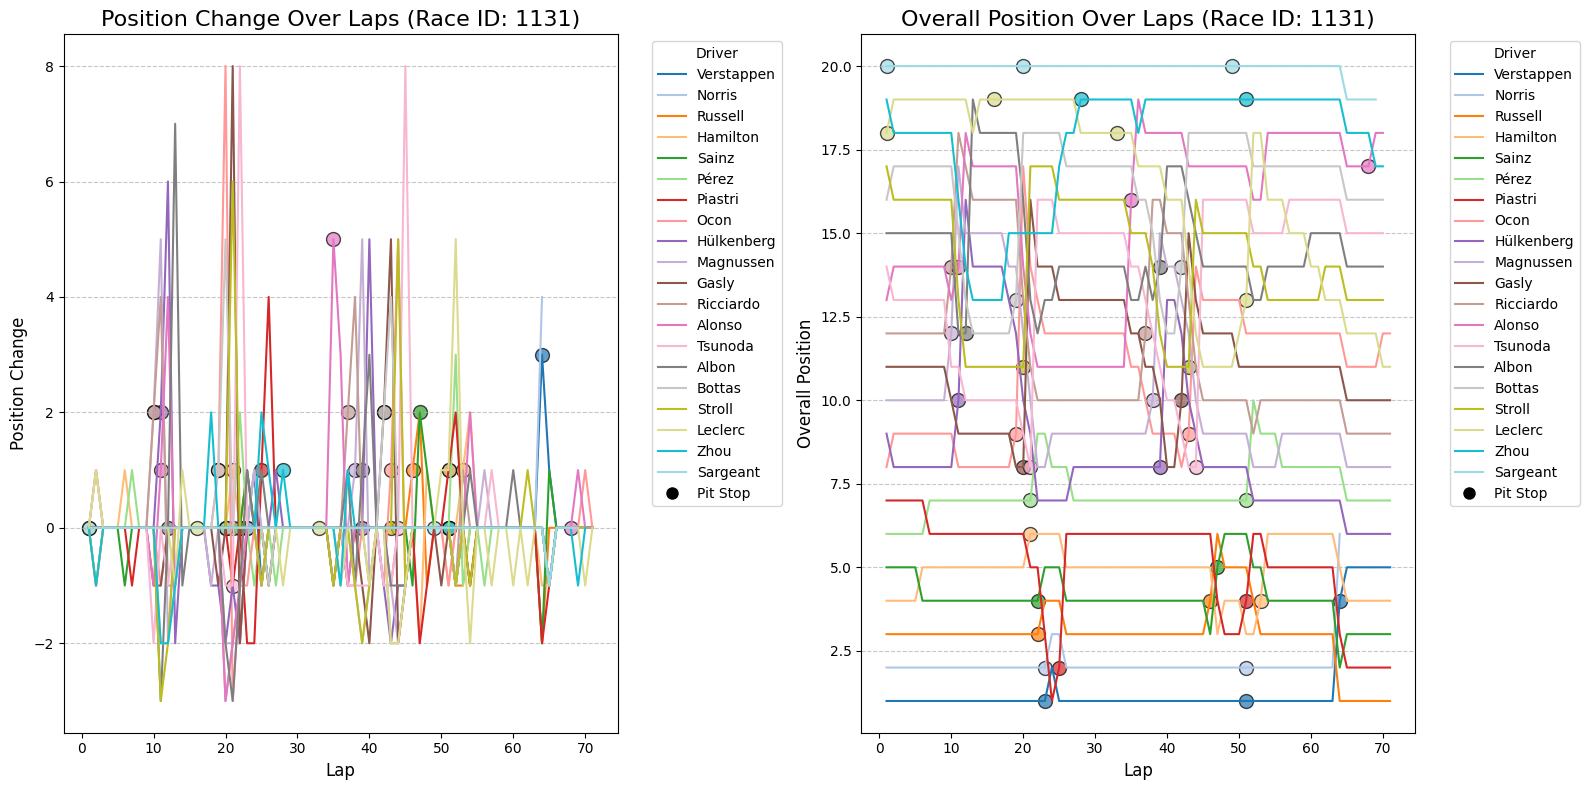

In [ ]:
# Select the most recent race ID
specific_race_id = final_df['raceId'].max()

# Filter the data for that race
race_df = final_df[final_df['raceId'] == specific_race_id]

# Set up fig
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
palette = sns.color_palette('tab20', n_colors=len(race_df['surname'].unique()))

# Plot Position Change
sns.lineplot(data=race_df, x='lap', y='position_change', hue='surname', palette=palette, ax=ax[0])

# Mark pitstops with a dot on the line (matching the color of the driver's line)
for i, driver in enumerate(race_df['surname'].unique()):
    driver_data = race_df[race_df['surname'] == driver]
    pitstops = driver_data[driver_data['pit_stop_taken'] == 1]
    ax[0].scatter(pitstops['lap'], pitstops['position_change'],
                  color=palette[i], s=100, edgecolors='black', marker='o', alpha=0.7)

ax[0].set_title(f'Position Change Over Laps (Race ID: {specific_race_id})', fontsize=16)
ax[0].set_xlabel('Lap', fontsize=12)
ax[0].set_ylabel('Position Change', fontsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot Overall Position Over Laps (Line plot)
sns.lineplot(data=race_df, x='lap', y='position', hue='surname', palette=palette, ax=ax[1])


for i, driver in enumerate(race_df['surname'].unique()):
    driver_data = race_df[race_df['surname'] == driver]
    pitstops = driver_data[driver_data['pit_stop_taken'] == 1]
    ax[1].scatter(pitstops['lap'], pitstops['position'],
                  color=palette[i], s=100, edgecolors='black', marker='o', alpha=0.7)

ax[1].set_title(f'Overall Position Over Laps (Race ID: {specific_race_id})', fontsize=16)
ax[1].set_xlabel('Lap', fontsize=12)
ax[1].set_ylabel('Overall Position', fontsize=12)
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

# Create custom legend entry for pit stops
pit_stop_legend = Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Pit Stop')

# Combine the legends
handles, labels = ax[0].get_legend_handles_labels()
handles.append(pit_stop_legend)
labels.append('Pit Stop')

# Add legened to plots
ax[0].legend(handles=handles, labels=labels, title='Driver', bbox_to_anchor=(1.05, 1), loc='upper left')
ax[1].legend(handles=handles, labels=labels, title='Driver', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show!
plt.tight_layout()
plt.show()


### 3.1.3.2: Pit Stops for a Specific Race (Bar Plot)

When compared with the previous plot, this secondary visualization becomes very important. For this specific race, Max Verstappen was in the lead nearly the entire time. However, a last second pit stop forced him to drop from first to fifth. Our dataset does not provide information as to why he had to take the pitstop, but we notice that his first two pitstops happened on similar lap numbers to the rest of the majority of the field.

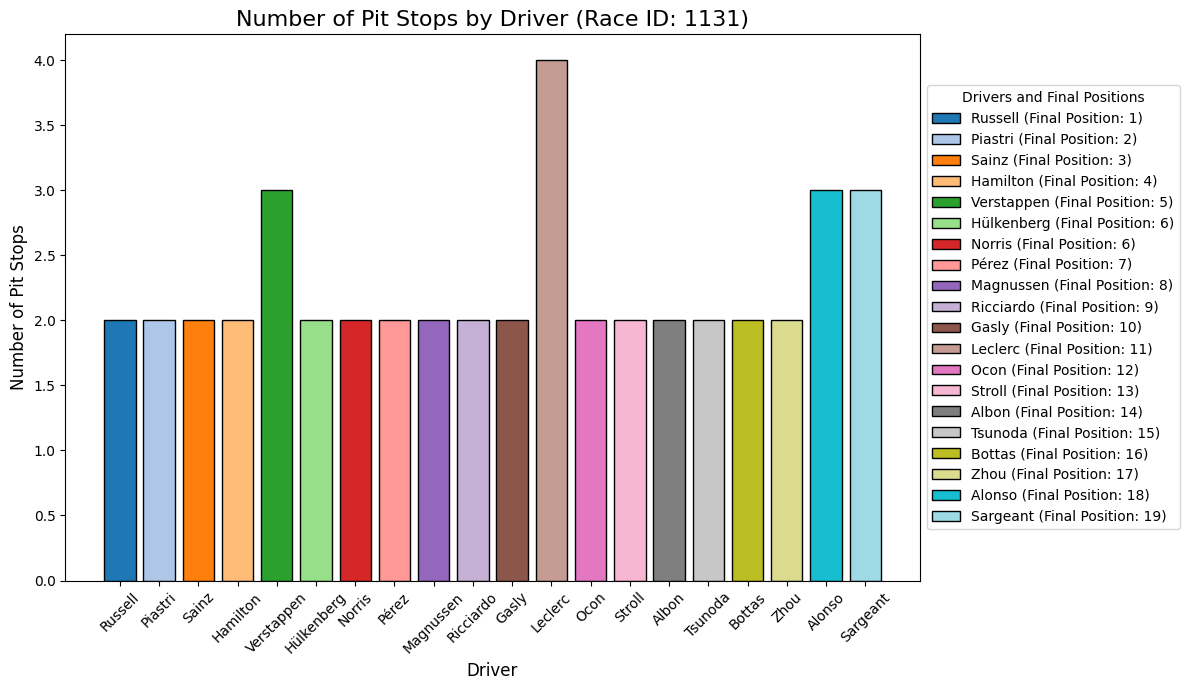

In [ ]:
# Filter the DataFrame for the most recent race
recent_race_df = final_df[final_df['raceId'] == specific_race_id]

# Calculate the number of pit stops for each driver in the race
pit_stop_counts = recent_race_df[recent_race_df['pit_stop_taken'] == 1].groupby('surname')['pit_stop_taken'].count()

# Determine each driver's final position in the race
final_positions = recent_race_df.groupby('surname')['position'].last()

# Combine pit stop counts with final positions, sorted by final position
data = pd.DataFrame({
    'pit_stops': pit_stop_counts,
    'final_position': final_positions
}).sort_values(by='final_position')

# Plot the pit stop counts, sorted by final position
plt.figure(figsize=(12, 7))
bars = plt.bar(data.index, data['pit_stops'], color=palette, edgecolor='black')

# Add a legend with driver names and their final positions
legend_labels = [
    f"{driver} (Final Position: {position})"
    for driver, position in data['final_position'].items()
]
plt.legend(
    bars,
    legend_labels,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    title="Drivers and Final Positions"
)

plt.title(f'Number of Pit Stops by Driver (Race ID: {specific_race_id})', fontsize=16)
plt.xlabel('Driver', fontsize=12)
plt.ylabel('Number of Pit Stops', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()

# Show!
plt.show()

### 3.1.4: Qualifying Performance Heatmap

This graphic shows us each driver's qualifying position over time. Evidently, many of the drivers with more red in their bar have shorter careers. Perhaps they lose their edge, or the teams want to replace them with drivers that experience more success. It would be interesting to overlay each driver's associated constructor on this map, which would give us more insight into whether drivers or constructors have a higher impact on performance.

<ipython-input-19-11cb2b7065e0>:21: FutureWarning: The provided callable <function min at 0x7b8068be4dc0> is currently using DataFrameGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df_qualifying_heatmap = df_qualifying_filtered.pivot_table(


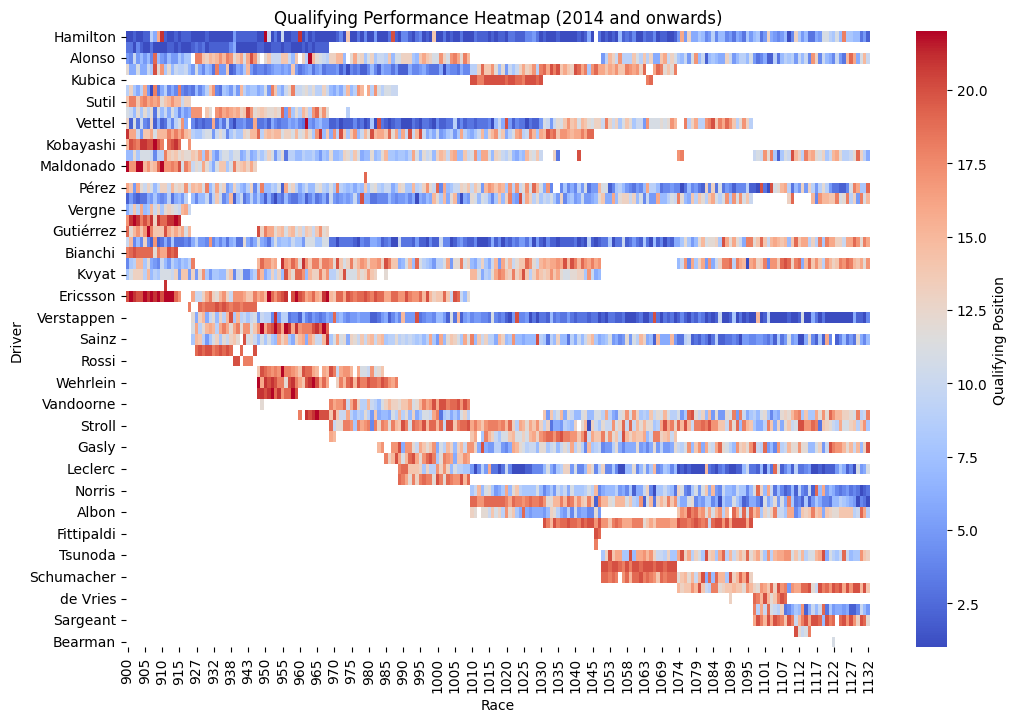

In [ ]:
df_qualifying = modified_dataframes['qualifying.csv']
df_surnames = modified_dataframes['drivers.csv'][['driverId', 'surname']]
df_races = modified_dataframes['races.csv'][['raceId', 'year', 'name', 'date']]

# Create a dictionary mapping driverId to surname
surname_mapping = df_surnames.set_index('driverId')['surname'].to_dict()

# Add the 'surname' column to df_qualifying using the mapping
df_qualifying['surname'] = df_qualifying['driverId'].map(surname_mapping)

# Remove any rows where surname is NaN (drivers without surnames)
df_qualifying = df_qualifying.dropna(subset=['surname'])

# Merge df_qualifying with df_races to filter for races from 2014 onwards
df_qualifying = df_qualifying.merge(df_races[['raceId', 'year']], on='raceId', how='left')

# Filter for years >= 2014
df_qualifying_filtered = df_qualifying[df_qualifying['year'] >= 2014]

# Create the heatmap data, indexing by driverId but showing surname on the y-axis
df_qualifying_heatmap = df_qualifying_filtered.pivot_table(
    index='driverId', columns='raceId', values='position', aggfunc=np.min
)

# Set the y-axis labels to the surnames instead of driverId
df_qualifying_heatmap.index = df_qualifying_heatmap.index.map(surname_mapping)

# Plot!
plt.figure(figsize=(12, 8))
sns.heatmap(df_qualifying_heatmap, cmap='coolwarm', cbar_kws={'label': 'Qualifying Position'})
plt.title('Qualifying Performance Heatmap (2014 and onwards)')
plt.xlabel('Race')
plt.ylabel('Driver')
plt.show()


### 3.1.5: Lap Times by Specific Race

This plot shows us that as drivers became more acquainted with a course, their lap times decreased. Furthermore, it shows us (in conjunction with previous plots) how devastating bad laps can be.

<ipython-input-20-a62b44612edd>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lap_times_filtered['surname'] = df_lap_times_filtered['driverId'].map(surname_mapping)


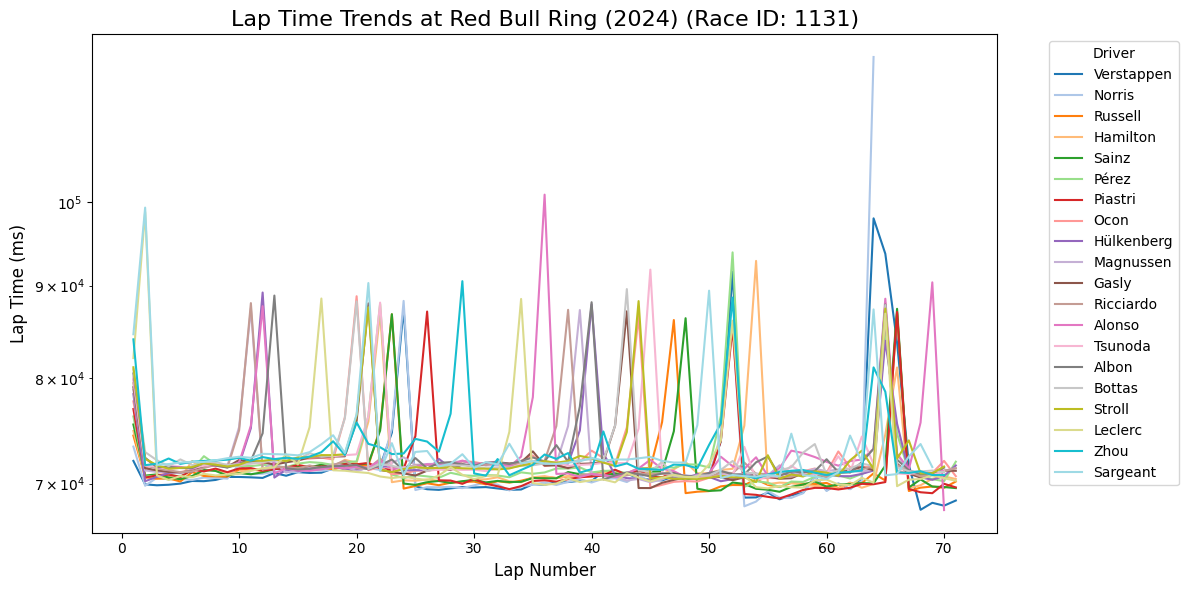

In [ ]:
df_lap_times = modified_dataframes['lap_times.csv']
df_surnames = modified_dataframes['drivers.csv'][['driverId', 'surname']]
df_circuits = modified_dataframes['circuits.csv'][['circuitId', 'name']]

# Specify the race we are interested in
specific_race_ids = [specific_race_id]

# Filter the lap times for the specified races
df_lap_times_filtered = df_lap_times[df_lap_times['raceId'].isin(specific_race_ids)]

# Create a dictionary mapping driverId to surname
surname_mapping = df_surnames.set_index('driverId')['surname'].to_dict()

# Add the surname to the lap times DataFrame using the mapping
df_lap_times_filtered['surname'] = df_lap_times_filtered['driverId'].map(surname_mapping)

# Merge the race data to get the circuit name and year
df_races = modified_dataframes['races.csv'][['raceId', 'circuitId', 'year']]
df_race_circuit = df_races[df_races['raceId'].isin(specific_race_ids)]

# Get the circuitId, circuit name, and year of the race
circuit_id = df_race_circuit['circuitId'].iloc[0]
circuit_name = df_circuits[df_circuits['circuitId'] == circuit_id]['name'].iloc[0]
race_year = df_race_circuit['year'].iloc[0]

# Plot
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_lap_times_filtered, x='lap', y='milliseconds', hue='surname', palette='tab20', errorbar=None)
plt.title(f'Lap Time Trends at {circuit_name} ({race_year}) (Race ID: {specific_race_ids[0]})', fontsize=16)
plt.xlabel('Lap Number', fontsize=12)
plt.ylabel('Lap Time (ms)', fontsize=12)
plt.yscale('log')
plt.legend(title='Driver', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.1.6: Impact of Start Position on Finish Over Time

This plot highlights the strong correlation between start position and finish position in Formula 1 races. Drivers starting in pole position (P1) often maintain their rank, emphasizing how crucial the starting grid is. Consistent front-runners have a significant advantage in securing top finishes over time.

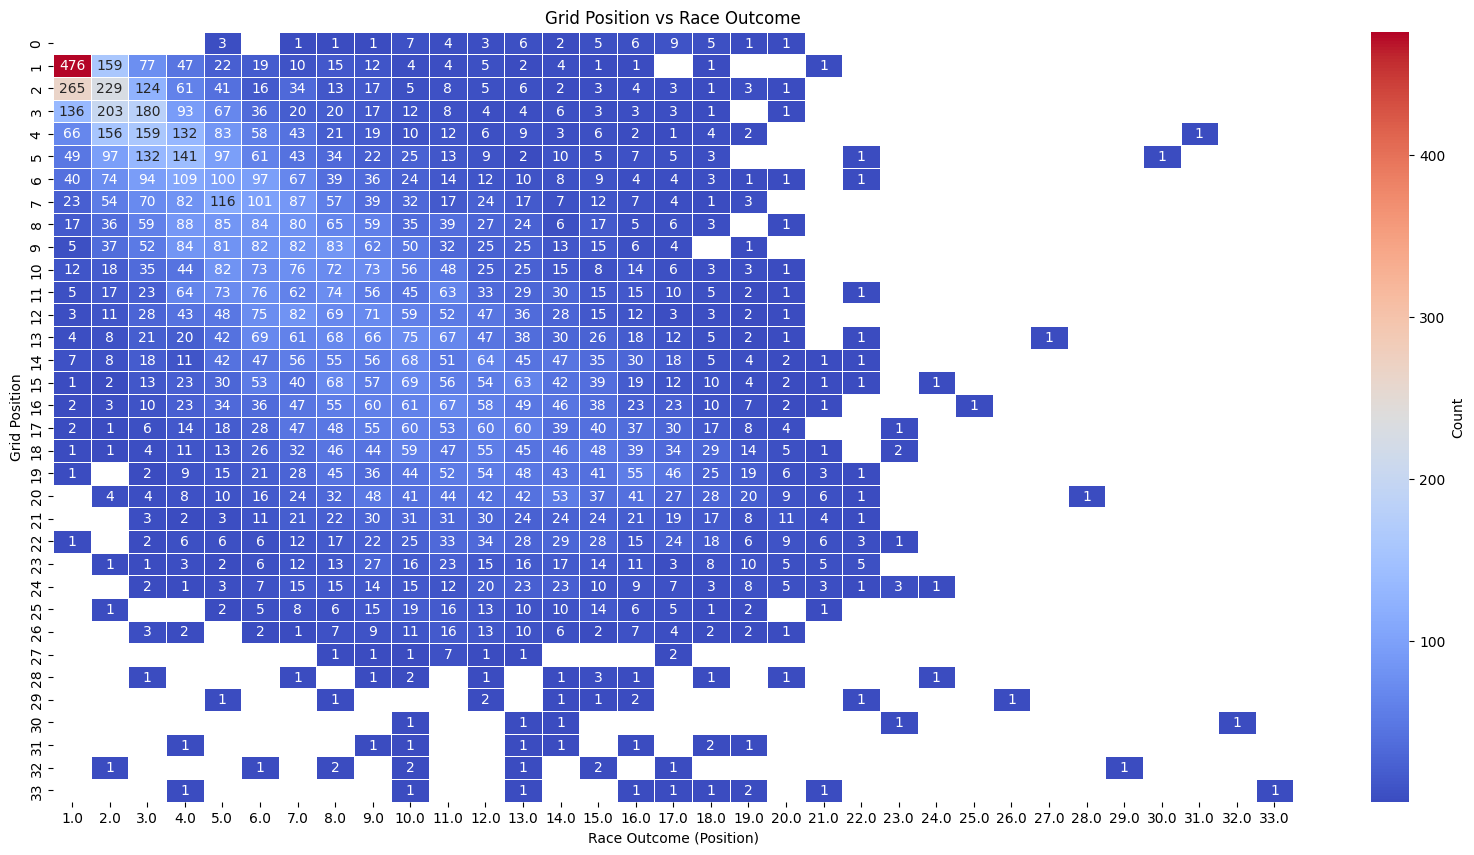

In [ ]:
df_results = modified_dataframes['results.csv']

# Create pivot table for grid vs outcome
df_grid_vs_outcome = df_results.pivot_table(
    index='grid', columns='position', values='resultId', aggfunc='count'
)

# Plot
plt.figure(figsize=(20, 10))
sns.heatmap(
    df_grid_vs_outcome,
    cmap='coolwarm',
    cbar_kws={'label': 'Count'},
    annot=True,
    fmt='g',
    linewidths=0.5
)
plt.title('Grid Position vs Race Outcome')
plt.xlabel('Race Outcome (Position)')
plt.ylabel('Grid Position')
plt.show()

### 3.1.7: Investigating Potential Yellow Flag Events

Ultimately, the work in this section might be used to identify whether or not drivers take pitstops during yellow flags. During pitstops, they might be more inclined to exchange their tires, which could impact their race strategy. In this section, the foundation for identifying (imperfectly, because we have a hole in our dataset) when yellow flags occur is implemented.

In [ ]:
# Upload dataframes
results = modified_dataframes['results.csv']
drivers = modified_dataframes['drivers.csv']
constructors = modified_dataframes['constructors.csv']
races = modified_dataframes['races.csv']
circuits = modified_dataframes['circuits.csv']
status = modified_dataframes['status.csv']

# Filter for yellow flag events based on status descriptions
# We can assume that accidents, collisions, damage, debris, or fire might trigger one
yellow_flag_status = status[status['status'].str.contains(
    "Collision|Accident|Fatal accident|Safety|Damage|Debris|Fire",
    case=False)]
yellow_flag_events = results[results['statusId'].isin(yellow_flag_status['statusId'])]

# Merging dfs
yellow_flag_details = (
    yellow_flag_events
    .merge(drivers, on='driverId', how='left', suffixes=('', '_driver'))
    .merge(constructors, on='constructorId', how='left', suffixes=('', '_constructor'))
    .merge(races, on='raceId', how='left', suffixes=('', '_race'))
    .merge(circuits, on='circuitId', how='left', suffixes=('', '_circuit'))
    .merge(status, on='statusId', how='left', suffixes=('', '_status'))
)

# Select and retain relevant columns
columns_to_keep = [
    'raceId', 'year', 'round', 'name_race', 'location', 'status',
    'forename', 'surname', 'constructorRef', 'grid', 'position', 'laps', 'time'
]
detailed_yellow_flags = yellow_flag_details[columns_to_keep]

# Sort by raceId and then by laps in ascending order
sorted_yellow_flags = detailed_yellow_flags.sort_values(by=['raceId', 'laps'], ascending=[True, True])
print("Sorted Yellow Flag Events with Incident Times:")

sorted_yellow_flags.head(50)

Sorted Yellow Flag Events with Incident Times:


,raceId,year,round,name_race,location,status,forename,surname,constructorRef,grid,position,laps,time
584,1,2009,1,Australian Grand Prix,Melbourne,Collision,Heikki,Kovalainen,mclaren,12,NaN,0,NaN
583,1,2009,1,Australian Grand Prix,Melbourne,Accident,Kazuki,Nakajima,williams,11,NaN,17,NaN
582,1,2009,1,Australian Grand Prix,Melbourne,Collision,Robert,Kubica,bmw_sauber,4,14.0,55,NaN
581,1,2009,1,Australian Grand Prix,Melbourne,Collision,Sebastian,Vettel,red_bull,3,13.0,56,NaN
585,3,2009,3,Chinese Grand Prix,Shanghai,Collision,Jarno,Trulli,toyota,6,NaN,18,NaN
586,5,2009,5,Spanish Grand Prix,Montmeló,Collision,Jarno,Trulli,toyota,7,NaN,0,NaN
587,5,2009,5,Spanish Grand Prix,Montmeló,Collision,Sébastien,Buemi,toro_rosso,15,NaN,0,NaN
588,5,2009,5,Spanish Grand Prix,Montmeló,Collision,Sébastien,Bourdais,toro_rosso,17,NaN,0,NaN
589,5,2009,5,Spanish Grand Prix,Montmeló,Collision,Adrian,Sutil,force_india,19,NaN,0,NaN
593,6,2009,6,Monaco Grand Prix,Monte-Carlo,Collision,Nelson,Piquet Jr.,renault,12,NaN,10,NaN


# SECTION 4: Models and Base Pipeline



## 4.1: Baseline Model Implementation

**If you are reading, section 4.1 is still under development and not related to sections 4.2 and 4.3. Please move to the complete models in 4.2 and 4.3!**

### 4.1.1: Combining Dataframes

Combining csvs to create a cohesive dataframe with all the necessary data.

In [ ]:
qualifying = modified_dataframes['qualifying.csv']
results = modified_dataframes['results.csv']
pit_stops = modified_dataframes['pit_stops.csv']
constructor_standings = modified_dataframes['constructor_standings.csv']
constructors = modified_dataframes['constructors.csv']

# Merge qualifying and results to get driver's starting position and final position
qualifying_results = pd.merge(qualifying, results, on=['raceId', 'driverId'], how='inner')

# Calculate position change (final position - starting position)
qualifying_results['position_change'] = qualifying_results['position_x'] - qualifying_results['grid']

# Merge pit stop data (total number of pit stops and total pit stop time)
pit_stop_summary = pit_stops.groupby(['raceId', 'driverId']).agg(
    pit_stop_count=('lap', 'nunique'),
    total_pit_stop_time=('milliseconds', 'sum')
).reset_index()


# Merge constructor standings (total constructor points)
constructor_summary = constructor_standings[['raceId', 'constructorId', 'points']]
constructor_summary = pd.merge(constructor_summary, constructors[['constructorId', 'name']], on='constructorId', how='left')

# Merge everything into a single df
model_data = pd.merge(qualifying_results, pit_stop_summary, on=['raceId', 'driverId'], how='inner')
model_data = pd.merge(model_data, constructor_summary, on='raceId', how='left')

model_data=model_data.drop(columns=['constructorId', 'points_y', 'name'])
model_data=model_data.drop_duplicates()
model_data = model_data.merge(races[['raceId', 'year']], on='raceId', how='left')
print(model_data)

      qualifyId  raceId  driverId  constructorId_x  number_x  position_x  \
0          4537     841        20                9         1           1   
1          4538     841         1                1         3           2   
2          4539     841        17                9         2           3   
3          4540     841        18                1         4           4   
4          4541     841         4                6         5           5   
...         ...     ...       ...              ...       ...         ...   
5321      10306    1132       817              215         3          15   
5322      10307    1132       822               15        77          16   
5323      10308    1132       825              210        20          17   
5324      10309    1132       839              214        31          18   
5325      10310    1132       815                9        11          19   

            q1        q2        q3    surname  ...  milliseconds  fastestLap  \
0     1

In [ ]:
# Function to convert lap times from strings to seconds
def convert_time_to_seconds(time_str):
    if pd.isna(time_str):
        return None
    try:
        minutes, seconds = time_str.split(':')
        return int(minutes) * 60 + float(seconds)
    except ValueError:
        return None

# Convert fastestLapTime to seconds
model_data['lap_time_seconds'] = model_data['fastestLapTime'].apply(convert_time_to_seconds)

# Calculate average lap time per race and constructor
model_data['average_lap_time'] = model_data.groupby(['raceId', 'constructorId_x'])['lap_time_seconds'].transform('mean')

# Calculate average pit stop time per race and constructor
model_data['average_pit_stop_time'] = model_data.groupby(['raceId', 'constructorId_x'])['total_pit_stop_time'].transform('mean')

print(model_data[['raceId', 'constructorId_x', 'average_lap_time', 'average_pit_stop_time']].drop_duplicates().head())

   raceId  constructorId_x  average_lap_time  average_pit_stop_time
0     841                9           89.7220                59407.5
1     841                1           90.0985                54638.5
4     841                6           89.2170                72301.0
5     841                4           91.2205                49155.0
6     841              131           94.4110                36362.5


Our baseline model is using metrics that already exist and a simple RandomForestRegressor to predict the outcome of the season. Our goal is to improve upon this model via improving model accuracy. We use data up until 2022 as training data, 2023 as validation data and then 2024 as test data.

In [ ]:
# Select features and target variable
features = ['grid', 'average_lap_time', 'average_pit_stop_time', 'position_change']
target = 'points_x'


train_data = model_data[model_data['year'] <= 2022]  # Data up to 2022
val_data = model_data[model_data['year'] == 2023]    # Data for 2023
test_data = model_data[model_data['year'] == 2024]   # Data for 2024

# Separate features and targets for each set
X_train = train_data[features]
y_train = train_data[target]

X_val = val_data[features]
y_val = val_data[target]

X_test = test_data[features]
y_test = test_data[target]


# Train a RandomForest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")

# Feature importance
importances = model.feature_importances_
for feature, importance in zip(features, importances):
    print(f"{feature}: {importance:.4f}")


Mean Absolute Error: 3.73
grid: 0.5817
average_lap_time: 0.1853
average_pit_stop_time: 0.1873
position_change: 0.0457


<ipython-input-26-b905549f1c23>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


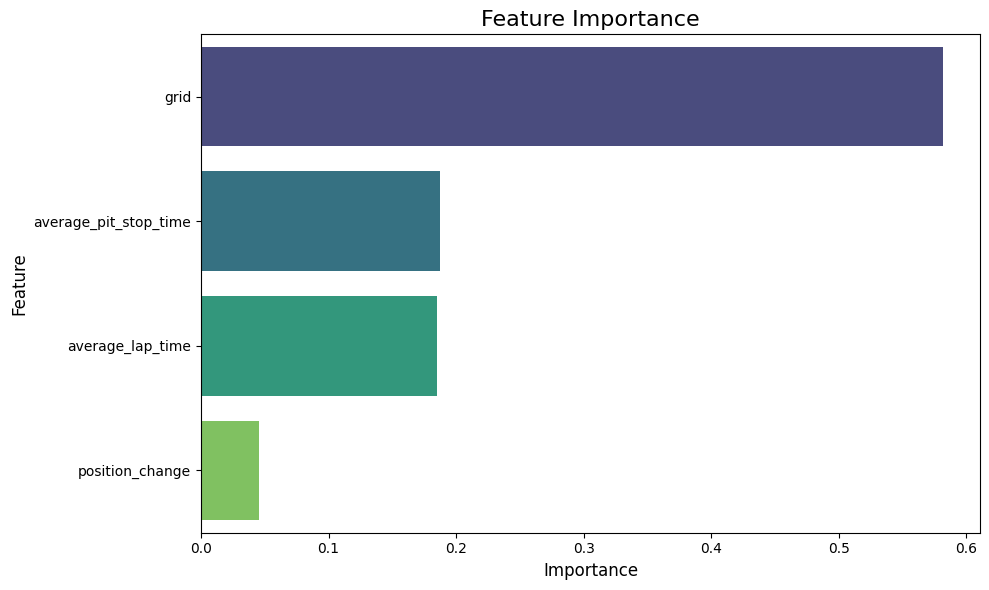

In [ ]:
importances = model.feature_importances_

# Create a df for plot
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
})

# Sort the features by importance and plot
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

### 4.1.2 Clarifying Strategy vs. Constructor vs. Skill Through Additional Feature Engineering (Incomplete as of MS4)

To this point, we considered explicitly extracting strategy, constructor strength, and skill through feature engineering. However, it proved quite difficult to quauntify strategy independent of other factors without introducing new data on tires to report race telemetry. Therefore, we may abandon this approach or these features below will be used in a comparision of constructor vs. skill/strategy which we may need to combine, depending on how we decide to adjust our research question.

**Constructor variables:** *CarStrength* (measured via averaging the fastest qualification times of each constructor's racer.  We then create a strength score to for each individual race.  Our stegnth score is shown below and is from 0-1 where 1 represents the strongest preformer that day.


$[ S_i = \frac{T_{max} - T_i}{T_{max} - T_{min}} ]$



We use  qualification because cars are the same weight
during this process which eliminates weight confound. Likewise, during qualifying races, there's an absence of other racers obstructing performance. Additionally, during qualifying drivers have no regard for tire management since they are trying to get the fastest time possible each lap.  We then average this strengh score for each race every season to get the team strength score that year.  By doing strength score for each individual race instead of averaging the lap times across the season, we get a more fair representation of how strong a specific team was across seasons.  If a team is much more dominant one season, it will be shown in its CarStrength score that season.

*ConstructorPitStopStrength* - This is important beacuse teams try and hire the best mechanics to make pitstop times as fast as possible.  The skill of the pit stop crew is shared by both races in each team becasue they go to the same pit stop crew.  Natually, teams pracitce their pit stop and are better than others.  We construct a pit stop strength score in a similar way to Car Strength by averaging pit stop times by race and construction a strength score for each individual race.  We then average that strengths score across the other strength scores in the season.

While they differ by only seconds, time in pitstop matters a lot for positioning because drivers are often forced to take pitstops at the same time.

In [ ]:
races = modified_dataframes['races.csv']

try:
  def convert_time_to_seconds(time_str):
      if pd.isna(time_str):
          return None
      minutes, seconds = time_str.split(':')
      return int(minutes) * 60 + float(seconds)
  model_data['q1'] = model_data['q1'].apply(convert_time_to_seconds)
  # Calculate the average q1 for each group of raceId and constructorId_x
  model_data['averageQ1'] = model_data.groupby(['raceId', 'constructorId_x'])['q1'].transform('mean')

  # Standardize the averageQ1 for each raceId from 0-1 where 1 is the fastest time
  model_data['eachScore'] = model_data.groupby('raceId')['averageQ1'].transform(lambda x: (x.max() - x) / (x.max() - x.min()))

  # Add a column called seasonStrength which averages eachScore by constructorId_x for each year
  model_data['CarStrength'] = model_data.groupby(['year', 'constructorId_x'])['eachScore'].transform('mean')
except:
    print('already ran')

In [ ]:
# now do the same for pitstop strength by changing q1 to pitstop time
try:
    # Convert pit stop time to seconds if necessary (already in milliseconds here, no conversion needed)

    # Calculate the average pit stop time for each group of raceId and constructorId_x
    model_data['averagePitStopTime'] = model_data.groupby(['raceId', 'constructorId_x'])['total_pit_stop_time'].transform('mean')

    # Standardize the averagePitStopTime for each raceId from 0-1 where 1 is the fastest pit stop time
    model_data['eachPitStopScore'] = model_data.groupby('raceId')['averagePitStopTime'].transform(
        lambda x: (x.max() - x) / (x.max() - x.min()) if x.max() > x.min() else 1
    )

    # Add a column called seasonStrengthScore which averages eachPitStopScore by constructorId_x for each year
    model_data['ConstructorPitStopStrength'] = model_data.groupby(['year', 'constructorId_x'])['eachPitStopScore'].transform('mean')

except Exception as e:
    print(f'Already ran or an error occurred: {e}')

In [ ]:
print(model_data)

      qualifyId  raceId  driverId  constructorId_x  number_x  position_x  \
0          4537     841        20                9         1           1   
1          4538     841         1                1         3           2   
2          4539     841        17                9         2           3   
3          4540     841        18                1         4           4   
4          4541     841         4                6         5           5   
...         ...     ...       ...              ...       ...         ...   
5321      10306    1132       817              215         3          15   
5322      10307    1132       822               15        77          16   
5323      10308    1132       825              210        20          17   
5324      10309    1132       839              214        31          18   
5325      10310    1132       815                9        11          19   

          q1        q2        q3    surname  ...  year  lap_time_seconds  \
0     85.29

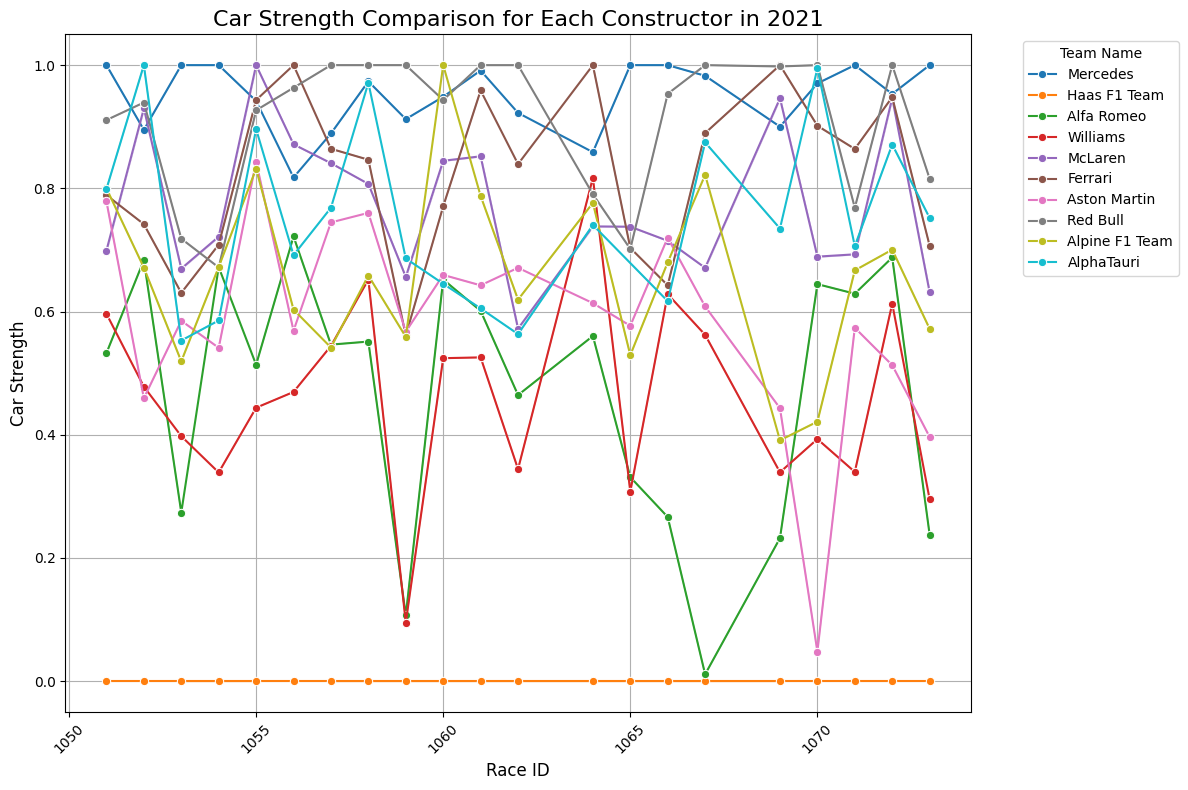

In [ ]:
# Assuming constructors.csv is in modified_dataframes
constructors = modified_dataframes['constructors.csv']
constructor_standings = modified_dataframes['constructor_standings.csv']

# Merge constructor names into model_data using constructorId_x
constructor_name_mapping = constructors[['constructorId', 'name']].rename(columns={'constructorId': 'constructorId_x'})
model_data = pd.merge(model_data, constructor_name_mapping, on='constructorId_x', how='left')

# Specify the year for comparison
selected_year = 2021  # Replace with the desired year

# Filter the data for the selected year
filtered_data = model_data[model_data['year'] == selected_year]

# Sort by raceId to ensure chronological order for plotting
filtered_data = filtered_data.sort_values(by='raceId')

# Create the plot
plt.figure(figsize=(12, 8))
sns.lineplot(data=filtered_data, x='raceId', y='eachScore', hue='name', marker='o', palette='tab10')

# Customize the plot
plt.title(f'Car Strength Comparison for Each Constructor in {selected_year}', fontsize=16)
plt.xlabel('Race ID', fontsize=12)
plt.ylabel('Car Strength', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Team Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
# Select features and target variable
features = ['CarStrength', 'ConstructorPitStopStrength']
target = 'points_x'

train_data = model_data[model_data['year'] <= 2022]
val_data = model_data[model_data['year'] == 2023]
test_data = model_data[model_data['year'] == 2024]

# Separate features and targets for each set
X_train = train_data[features]
y_train = train_data[target]

X_val = val_data[features]
y_val = val_data[target]

X_test = test_data[features]
y_test = test_data[target]


# Train a RandomForest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")

# Feature importance
importances = model.feature_importances_
for feature, importance in zip(features, importances):
    print(f"{feature}: {importance:.4f}")

Mean Absolute Error: 4.71
CarStrength: 0.8781
ConstructorPitStopStrength: 0.1219


### 4.1.3 An attempt at ranking via relative strength




In [ ]:
from sklearn.preprocessing import RobustScaler

# Load the necessary dataframes from modified_dataframes
constructor_standings = modified_dataframes['constructor_standings.csv']
driver_standings = modified_dataframes['driver_standings.csv']
results = modified_dataframes['results.csv']
races = modified_dataframes['races.csv']

# Merge results with races to get season information
results = pd.merge(results, races[['raceId', 'year']], on='raceId')

# Calculate Constructor Strength and merge with races for year info
constructor_strength_season = constructor_standings.groupby(['constructorId', 'raceId'])['points'].mean().reset_index()
constructor_strength_season.rename(columns={'points': 'ConstructorStrength'}, inplace=True)
constructor_strength_season = pd.merge(constructor_strength_season, races[['raceId', 'year']], on='raceId')

# Calculate Driver Strength by Season and merge with results for constructorId
driver_strength_season = driver_standings.groupby(['driverId', 'raceId'])['points'].sum().reset_index()
driver_strength_season.rename(columns={'points': 'DriverPoints'}, inplace=True)
driver_strength_season = pd.merge(driver_strength_season, results[['driverId', 'constructorId', 'year']].drop_duplicates(), on='driverId')

# Calculate relative driver strength within each constructor and season
driver_strength_season['RelativeDriverStrength'] = driver_strength_season.groupby(['year', 'constructorId'])['DriverPoints'].transform(lambda x: x / x.sum())

# Merge Driver Strength with Constructor Strength, and calculate adjusted strength
driver_strength_season = pd.merge(driver_strength_season, constructor_strength_season, on=['constructorId', 'raceId'])
driver_strength_season['AdjustedDriverStrength'] = driver_strength_season['RelativeDriverStrength'] / driver_strength_season['ConstructorStrength']

# Handle duplicate 'year' columns by renaming before merge or dropping
# Here, I rename the 'year' column coming from results
driver_strength_season.rename(columns={'year': 'year_x'}, inplace=True)
constructor_strength_season.rename(columns={'year': 'year_y'}, inplace=True)

# Calculate total driver points per season and merge
total_driver_points_season = driver_strength_season.groupby('year_x')['DriverPoints'].sum().reset_index()
total_driver_points_season.rename(columns={'DriverPoints': 'TotalDriverPoints'}, inplace=True)
driver_strength_season = pd.merge(driver_strength_season, total_driver_points_season, left_on='year_x', right_on='year_x')

# Global Ranking and Final Ranking Calculation
alpha = 0.88
driver_strength_season['GlobalDriverStrength'] = driver_strength_season['DriverPoints'] / driver_strength_season['TotalDriverPoints']
driver_strength_season['FinalRankingScore'] = (1 - alpha) * driver_strength_season['AdjustedDriverStrength'] + alpha * driver_strength_season['ConstructorStrength']

# Step 1: Clean the data by replacing NaN or infinity values with a suitable value (e.g., median or large finite number)
driver_strength_season['FinalRankingScore'] = driver_strength_season['FinalRankingScore'].replace([float('inf'), float('-inf')], pd.NA)
driver_strength_season['FinalRankingScore'] = driver_strength_season['FinalRankingScore'].fillna(driver_strength_season['FinalRankingScore'].median())

# Step 2: Standardize using RobustScaler (handles outliers better)
scaler = RobustScaler()
driver_strength_season['StandardizedFinalScore'] = scaler.fit_transform(driver_strength_season[['FinalRankingScore']])

# Step 3: Recalculate the rankings based on standardized score
driver_strength_season['DriverRank'] = driver_strength_season.groupby('year_x')['StandardizedFinalScore'].rank(ascending=False)
constructor_strength_season['ConstructorRank'] = constructor_strength_season.groupby('year_y')['ConstructorStrength'].rank(ascending=False)

# Output Rankings
print(driver_strength_season[['driverId', 'year_x', 'DriverRank', 'DriverPoints', 'ConstructorStrength', 'StandardizedFinalScore']])
print(constructor_strength_season[['constructorId', 'year_y', 'ConstructorRank', 'ConstructorStrength']])


        driverId  year_x  DriverRank  DriverPoints  ConstructorStrength  \
0              1    2008      2713.0           1.0                  1.0   
1              1    2007      3108.0           1.0                  1.0   
2              1    2009      3101.0           1.0                  1.0   
3              1    2010      3456.0           1.0                  1.0   
4              1    2011      3523.0           1.0                  1.0   
...          ...     ...         ...           ...                  ...   
198609       860    2024       572.5           6.0                252.0   
198610       860    2024       572.5           6.0                252.0   
198611       860    2024       524.0           6.0                270.0   
198612       860    2024       459.0           6.0                291.0   
198613       860    2024       437.0           6.0                302.0   

        StandardizedFinalScore  
0                    -0.545455  
1                    -0.545455  


<ipython-input-32-ed597687cdd4>:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  driver_strength_season['FinalRankingScore'] = driver_strength_season['FinalRankingScore'].fillna(driver_strength_season['FinalRankingScore'].median())


## 4.2 (New Model) Random Forest Classifier Model with Historical Elo Scores Supplementing

In [ ]:
# Load the results and races CSV files
results = modified_dataframes['results.csv']
races = modified_dataframes['races.csv']

# Merge the results with the races DataFrame to add the 'year' column from races.csv
results = results.merge(races[['raceId', 'year']], on='raceId', how='left')

# Show the merged data to confirm it worked
print(results.head())

# Initialize a dictionary to store Elo scores by driverId
elo_scores = {}

# Define Elo rating parameters
K = 30

# Function to calculate and update Elo ratings
def update_elo(winner_id, loser_id, elo_scores, K=30):
    winner_elo = elo_scores.get(winner_id, 1500)
    loser_elo = elo_scores.get(loser_id, 1500)
    expected_winner = 1 / (1 + 10 ** ((loser_elo - winner_elo) / 400))
    expected_loser = 1 / (1 + 10 ** ((winner_elo - loser_elo) / 400))
    elo_scores[winner_id] = winner_elo + K * (1 - expected_winner)
    elo_scores[loser_id] = loser_elo + K * (0 - expected_loser)

# Loop over the results data to update Elo scores
for _, row in results.iterrows():
    driver_id = row['driverId']
    position = row['position']

    # No restriction on number of drivers
    other_drivers = results[(results['raceId'] == row['raceId']) & (results['driverId'] != driver_id)]
    for _, other_row in other_drivers.iterrows():
        other_driver_id = other_row['driverId']
        other_position = other_row['position']
        if position == 1:
            update_elo(driver_id, other_driver_id, elo_scores)
        elif other_position == 1:
            update_elo(other_driver_id, driver_id, elo_scores)
        elif position < other_position:
            update_elo(driver_id, other_driver_id, elo_scores)
        elif position > other_position:
            update_elo(other_driver_id, driver_id, elo_scores)

# Create the 'elo_score' feature in the results DataFrame
results['elo_score'] = results['driverId'].map(elo_scores)

# Create a target variable by categorizing the position into 4 dynamic buckets
def categorize_position(row):
    total_drivers = len(results[results['raceId'] == row['raceId']])

    # Divide total drivers into 4 buckets
    bucket_size = total_drivers // 4
    if row['position'] <= bucket_size:
        return 0  # Top third
    elif row['position'] <= 2 * bucket_size:
        return 1  # Second third
    elif row['position'] <= 3 * bucket_size:
        return 2  # Third third
    else:
        return 3  # Bottom third

results['position_bucket'] = results.apply(categorize_position, axis=1)

   resultId  raceId  driverId  constructorId number  grid  position  \
0         1      18         1              1     22     1       1.0   
1         2      18         2              2      3     5       2.0   
2         3      18         3              3      7     7       3.0   
3         4      18         4              4      5    11       4.0   
4         5      18         5              1     23     3       5.0   

  positionText  positionOrder  points  laps         time  milliseconds  \
0            1              1    10.0    58  1:34:50.616     5690616.0   
1            2              2     8.0    58       +5.478     5696094.0   
2            3              3     6.0    58       +8.163     5698779.0   
3            4              4     5.0    58      +17.181     5707797.0   
4            5              5     4.0    58      +18.014     5708630.0   

   fastestLap  rank fastestLapTime fastestLapSpeed  statusId  year  
0        39.0   2.0       1:27.452         218.300         

In [ ]:
# Split data
train_data = results[results['year'] <= 2022]
val_data = results[results['year'] == 2023]
test_data = results[results['year'] == 2024]

# Define features and target (example features, adjust as needed)
features = ['elo_score', 'grid', 'rank', 'laps', 'constructorId']
target = 'position_bucket'  # Predicting the bucket as the target

# Prepare X and y for training
X_train = train_data[features]
y_train = train_data[target]
X_val = val_data[features]
y_val = val_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Initialize and train the random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the validation set
y_pred_44 = rf_model.predict(X_val)

# Evaluate the model's performance using accuracy and F1-score
accuracy = accuracy_score(y_val, y_pred_44)
f1 = f1_score(y_val, y_pred_44, average='weighted')  # Weighted F1-score for imbalanced classes
print(f'Accuracy on Validation Set: {accuracy}')
print(f'F1-Score on Validation Set: {f1}')

# Combine training and validation data after hyperparameter tuning
train_val_data = pd.concat([train_data, val_data])

# Prepare X and y for training on combined data
X_train_val = train_val_data[features]
y_train_val = train_val_data[target]

# Retrain the model on the combined data
rf_model_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_final.fit(X_train_val, y_train_val)

# Evaluate the model on the test set
y_test_pred_44 = rf_model_final.predict(X_test)
test_accuracy_final = accuracy_score(y_test, y_test_pred_44)
test_f1_final = f1_score(y_test, y_test_pred_44, average='weighted')

print(f'Accuracy on Final Test Set: {test_accuracy_final}')
print(f'F1-Score on Final Test Set: {test_f1_final}')


Accuracy on Validation Set: 0.6204545454545455
F1-Score on Validation Set: 0.6203462484123698
Accuracy on Final Test Set: 0.6276150627615062
F1-Score on Final Test Set: 0.6234768341708725


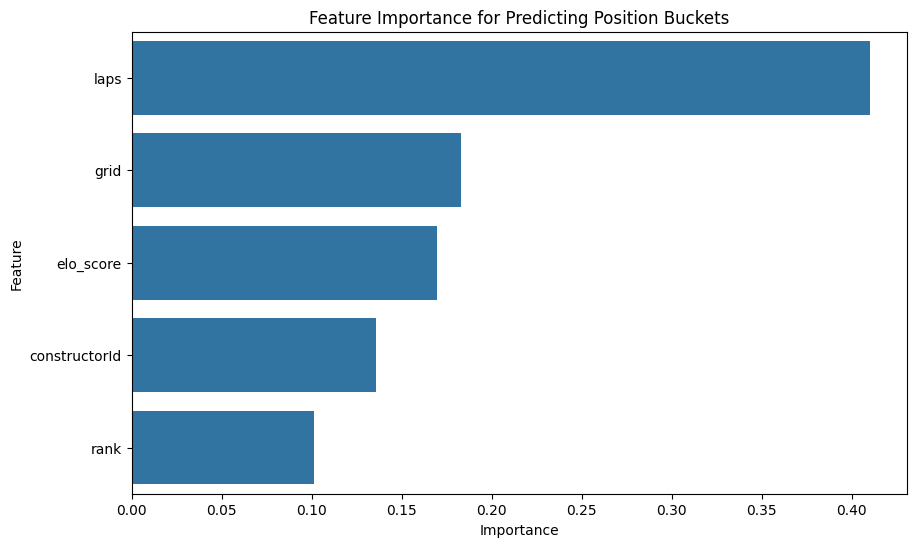

In [ ]:
# Plot feature importances from the random forest model
feature_importances = rf_model.feature_importances_
features_list = features

# Create a DataFrame for easier plotting
feature_df = pd.DataFrame({
    'feature': features_list,
    'importance': feature_importances
})

# Sort the features by importance
feature_df = feature_df.sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_df)
plt.title('Feature Importance for Predicting Position Buckets')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 4.3 (New Model) XG Boost Model

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score

# Initialize and train the XGBoost model
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict on the validation set
y_pred_45 = xgb_model.predict(X_val)

# Evaluate the model's performance using accuracy and F1-score
accuracy = accuracy_score(y_val, y_pred_45)
f1 = f1_score(y_val, y_pred_45, average='weighted')  # Weighted F1-score for imbalanced classes
print(f'Accuracy on Validation Set: {accuracy}')
print(f'F1-Score on Validation Set: {f1}')

# Combine training and validation data after hyperparameter tuning
train_val_data = pd.concat([train_data, val_data])

# Prepare X and y for training on combined data
X_train_val = train_val_data[features]
y_train_val = train_val_data[target]

# Retrain the model on the combined data
xgb_model_final = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_model_final.fit(X_train_val, y_train_val)

# Evaluate the model on the test set
y_test_pred_45 = xgb_model_final.predict(X_test)
test_accuracy_final = accuracy_score(y_test, y_test_pred_45)
test_f1_final = f1_score(y_test, y_test_pred_45, average='weighted')

print(f'Accuracy on Final Test Set: {test_accuracy_final}')
print(f'F1-Score on Final Test Set: {test_f1_final}')

Accuracy on Validation Set: 0.6113636363636363
F1-Score on Validation Set: 0.6154825162899811
Accuracy on Final Test Set: 0.6276150627615062
F1-Score on Final Test Set: 0.6180419259682363


# SECTION 5: Interpretation of Model and Results

Overall, to this point neither of our two models appear to have particular high performance in terms of accuracy with our first model, a random forest classifier with historical elo scores supplementing the creation of 4 position buckets with about a 62% accuracy and F1 score across the validation and final test set while the second model, a XG Boost Model had about a 61-62% accuracy and F1 score across the validation and test sets. This implies that for both these models, the models correctly predicted approximately 61-62% of the validation set samples. This result implies that the model is not particularly good at predicting which bucket a car is finishing in: it is likely to be predicting the top and bottom well.

For our F1 model, XGBoost and Random Forest Classifier differ in how they build decision trees, which we covered in lectures 17, 20, and 21. Random Forest creates several decision trees independently and combines their predictions, which helps prevent overfitting and works well with F1 data. XGBoost, on the other hand, uses gradient boosting, where each tree is built one after another to fix the mistakes of the previous one, often giving better accuracy with complex datasets. But despite XGBoost's usual edge, our results showed that the Random Forest model actually gave us better F1 and accuracy scores for predicting driver performance.

## 5.1 Analysis of Random Forest Classifier Model w/ Elo Scores (4.4)

### 5.1.1 Confusion Matrix Analysis

<Figure size 800x600 with 0 Axes>

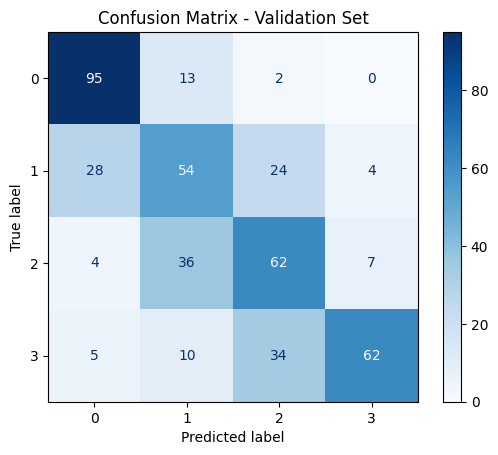

<Figure size 800x600 with 0 Axes>

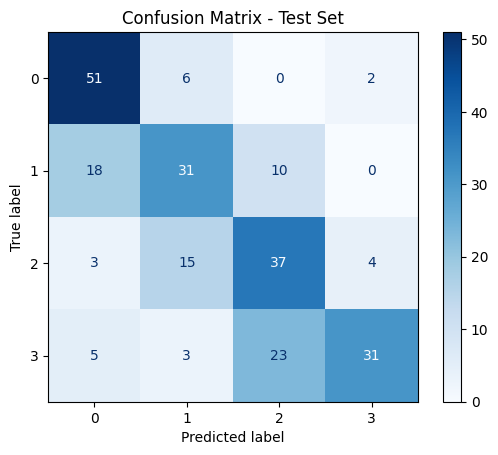

In [ ]:
# Confusion Matrix for Validation Set
cm_val = confusion_matrix(y_val, y_pred_44)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=rf_model.classes_)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
disp_val.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Validation Set')
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred_44)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=rf_model_final.classes_)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
disp_test.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.show()

These Confusion matrices imply that of the performance buckets we have established, Class 1 seems harder to distinguish, with a significant number of samples misclassified as Class 0 and Class 2. Class 3 also has notable confusion with Class 2. This confusion in middle classes implies that although we are accurately able to predict the fastest drivers and the slowest, distinguishing among the middle of the pack is much more difficult, a particular area of interest for us to look into.

### 5.1.2 ROC Curve

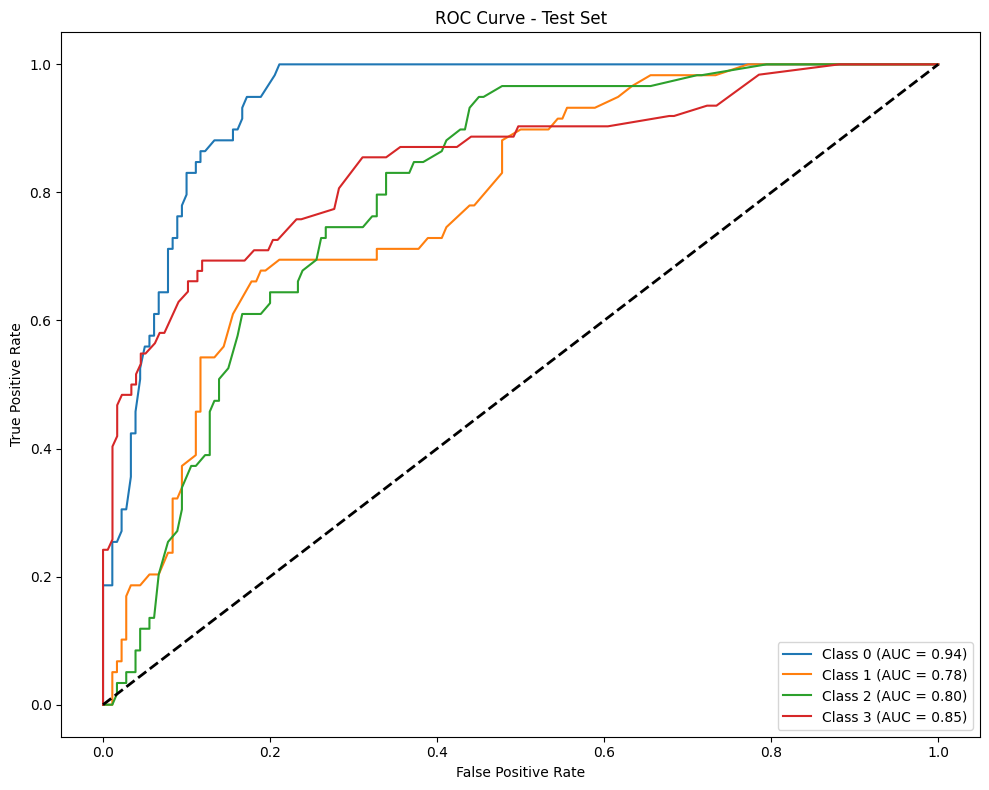

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

# Binarize the output for ROC Curve (One-vs-Rest for multiclass)
y_test_binarized = label_binarize(y_test, classes=rf_model.classes_)

# Plot ROC Curve for each class
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(rf_model.classes_):
    y_score = rf_model_final.predict_proba(X_test)[:, i]  # Probabilities for class i
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc:.2f})")

# Plot diagonal line for random guessing
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('ROC Curve - Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

By AUC, we again see that Class 0 and Class 3 are the most easily classified. Additionally, Class 0 quickly reaches a 1.0 true positive rate against its false positives implying that are model is best for predicting the fatest bucket but struggles beyond that.

## 5.2 Analysis of XG Boost Model (4.5)

### 5.2.1 Confusion Matrix Analysis

<Figure size 800x600 with 0 Axes>

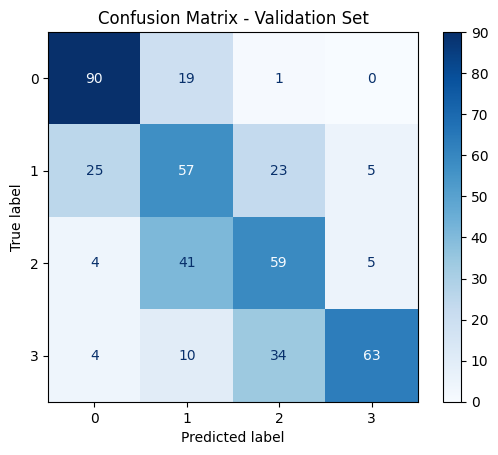

<Figure size 800x600 with 0 Axes>

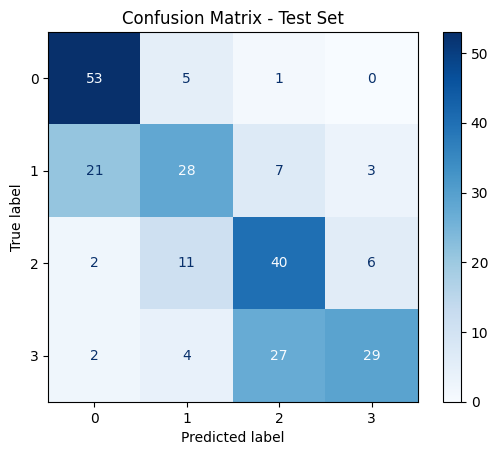

In [ ]:
# Confusion Matrix for Validation Set
cm_val = confusion_matrix(y_val, y_pred_45)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=xgb_model.classes_)

plt.figure(figsize=(8, 6))
disp_val.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Validation Set')
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred_45)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=xgb_model_final.classes_)

plt.figure(figsize=(8, 6))
disp_test.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.show()

There appears to more greater misclassification in these matrices compared to the prior 4.4 model despite the improvements XG Boost should introduce. We intend to investigate further these misclassifications particularly between labels 0 and 1 in this XG Boost model which were not present in our 4.4 model.

### 5.2.2 Calibration Curve (outside of class scope analysis)

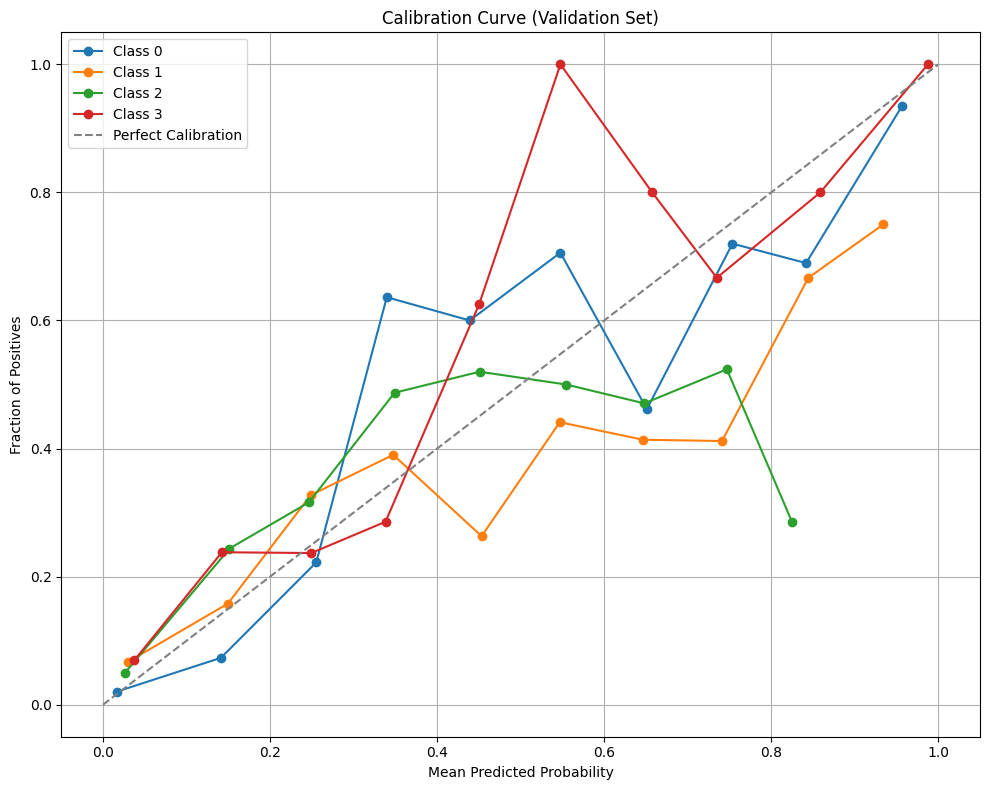

In [ ]:
# Generate predicted probabilities for the validation set
y_prob = xgb_model.predict_proba(X_val)

# Plot the calibration curve for each class
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(xgb_model.classes_):
    prob_true, prob_pred = calibration_curve((y_val == class_label).astype(int), y_prob[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Class {class_label}')

# Plot the perfect calibration line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

# Customize the plot
plt.title('Calibration Curve (Validation Set)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Section 6: Final Model Pipeline

Roadmap for end of CoLab: Up until 2022, we have already developed a metric that calculates the strength of each driver and constructor on a seasonal basis (the output is hidden in the above cells). Our goal is to incorporate this data into the Elo score calculations to refine the model's accuracy. Additionally, we aim to optimize the parameter selection within the Elo framework, as the current approach seems overly sensitive. Since Elo scores are adjusted based on a driver's performance relative to others, we plan to conduct a comprehensive sensitivity analysis to identify a more optimal K-factor.

We also intend to enhance the model’s predictive power by incorporating additional features. Currently, we are only utilizing features from two CSV files, limiting the potential of our dataset. By integrating features like pit stop metrics, tire selection, and driver experience (e.g., time spent in F1), we believe we can significantly improve the model's accuracy. We plan to explore feature engineering and optimization techniques, and we are particularly interested in applying Bayesian optimization, a method not previously explored in the course. Before the submission deadline, we will delve deeper into this technique and test its applicability to our model, expanding beyond the limits of lecture.

Lastly, we aim to better account for the dynamic nature of F1, particularly the introduction of new teams and drivers each season. Unlike traditional sports leagues where team rosters remain relatively stable, F1 experiences significant fluctuations that present a unique modeling challenge. We are excited about the path ahead and confident that these improvements will enhance our accuracy by up to 20%.